# BITS WILP – SEM 2 DRL Assignment Part 2
## Autonomous Drone Rescue Using Dynamic Programming

**Student ID / Group ID:** `2025ab05032`

---

### Student ID Configuration Derivation

| Parameter | Rule | Derived Value |
|---|---|---|
| Last digit of ID | `2025ab05032` → last digit = **2** | 2 ∈ [0-4] |
| Grid size | 0-4 → 5×5 | **5 × 5** |
| Objects | 0-4 → 2R, 1C, 3D, 2X | **2 Rescue, 1 Charger, 3 Danger, 2 Blocked** |
| Max battery | even digit → 10 | **10 units** |
| Wind probability | 0-4 → 20% | **20%** |
| Max steps | 5×5 grid → 50 | **50 steps** |

---

### Grid Layout

```
  Col:  0    1    2    3    4
Row 0: [ S ] [ F ] [ D ] [ F ] [ F ]
Row 1: [ F ] [ X ] [ F ] [ D ] [ R ]
Row 2: [ W ] [ F ] [ C ] [ F ] [ F ]
Row 3: [ D ] [ F ] [ F ] [ X ] [ F ]
Row 4: [ F ] [ F ] [ R ] [ F ] [ W ]
```

| Symbol | Position(s) | Count |
|--------|-------------|-------|
| S – Start | (0,0) | 1 |
| F – Free | (0,1),(0,3),(0,4),(1,0),(1,2),(2,1),(2,3),(2,4),(3,1),(3,2),(3,4),(4,0),(4,1),(4,3) | 14 |
| D – Danger | (0,2),(1,3),(3,0) | 3 ✓ |
| R – Rescue | (1,4),(4,2) | 2 ✓ |
| C – Charging | (2,2) | 1 ✓ |
| W – Wind | (2,0),(4,4) | 2 |
| X – Blocked | (1,1),(3,3) | 2 ✓ |

---

### State Representation

Each state is a 4-tuple: `(row, col, battery, rescue_mask)`

- **`row`, `col`** – Drone position (0-indexed)
- **`battery`** – Current battery level: integer in [0, 10]
- **`rescue_mask`** – 2-bit integer: bit-0 = rescue at (1,4), bit-1 = rescue at (4,2)
  - `0b00 = 0` → neither rescued
  - `0b01 = 1` → (1,4) rescued
  - `0b10 = 2` → (4,2) rescued
  - `0b11 = 3` → both rescued (terminal)

**Total state space:** 23 valid positions × 10 battery levels × 4 rescue states = **920 states**

---

### Reward Structure

| Event | Reward |
|-------|--------|
| Move to free cell (F, S, W) | −1 |
| Enter danger zone (D) | −10 |
| Reach unrescued rescue target (R) | +20 |
| Reach charging station (C) via movement | +5 (battery → MAX) |
| Hover on charging station (C) | 0 (battery += 2, capped at MAX) |
| Battery exhausted (hits 0) | −20 (terminal penalty) |

### Transition Dynamics

- **Blocked/OOB movement**: Drone stays in place; battery still consumed.
- **Wind zones (W)**: If on W cell and taking a movement action — 80% move as intended, 20% uniformly random direction (Up/Down/Left/Right). If random direction is OOB/blocked, drone stays.
- **Entering C**: Battery becomes MAX regardless of prior level.
- **Hovering on C**: Battery = min(MAX, battery + 2); reward = 0 (no step penalty).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from collections import defaultdict
import time
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
print('Imports successful')

Imports successful


## Part 1 – Custom Drone Rescue Environment

In [2]:
# ─────────────────────────────────────────────
#  CONFIGURATION  (derived from ID 2025ab05032)
# ─────────────────────────────────────────────
GRID_SIZE    = 5
MAX_BATTERY  = 10
WIND_PROB    = 0.20
MAX_STEPS    = 50
GAMMA        = 0.99
THETA        = 1e-3

# Cell type constants
CELL_S, CELL_F, CELL_D = 'S', 'F', 'D'
CELL_R, CELL_C, CELL_W, CELL_X = 'R', 'C', 'W', 'X'

# Grid (row-major)
BASE_GRID = [
    ['S', 'F', 'D', 'F', 'F'],   # row 0
    ['F', 'X', 'F', 'D', 'R'],   # row 1
    ['W', 'F', 'C', 'F', 'F'],   # row 2
    ['D', 'F', 'F', 'X', 'F'],   # row 3
    ['F', 'F', 'R', 'F', 'W'],   # row 4
]

START_POS          = (0, 0)
RESCUE_POSITIONS   = [(1, 4), (4, 2)]      # bit-0, bit-1
CHARGING_POSITIONS = [(2, 2)]
DANGER_POSITIONS   = [(0, 2), (1, 3), (3, 0)]
BLOCKED_POSITIONS  = frozenset([(1, 1), (3, 3)])
WIND_POSITIONS     = frozenset([(2, 0), (4, 4)])
ALL_RESCUED_MASK   = (1 << len(RESCUE_POSITIONS)) - 1  # 0b11 = 3

# Actions
UP, DOWN, LEFT, RIGHT, HOVER = 0, 1, 2, 3, 4
ACTIONS      = [UP, DOWN, LEFT, RIGHT, HOVER]
ACTION_NAMES = ['Up', 'Down', 'Left', 'Right', 'Hover']
DELTA = {UP: (-1, 0), DOWN: (1, 0), LEFT: (0, -1), RIGHT: (0, 1)}

# Rewards
R_RESCUE    =  20
R_DANGER    = -10
R_DEAD      = -20
R_CHARGE    =   5
R_MOVE      =  -1
R_HOVER_C   =   0   # hover on charger: no step penalty

print('Configuration loaded.')
print(f'Grid: {GRID_SIZE}x{GRID_SIZE}  |  Max battery: {MAX_BATTERY}  |  Wind prob: {WIND_PROB*100:.0f}%')
print(f'Rescue targets: {RESCUE_POSITIONS}')
print(f'Charging station: {CHARGING_POSITIONS}')
print(f'Danger zones: {DANGER_POSITIONS}')
print(f'Blocked cells: {sorted(BLOCKED_POSITIONS)}')

Configuration loaded.
Grid: 5x5  |  Max battery: 10  |  Wind prob: 20%
Rescue targets: [(1, 4), (4, 2)]
Charging station: [(2, 2)]
Danger zones: [(0, 2), (1, 3), (3, 0)]
Blocked cells: [(1, 1), (3, 3)]


In [3]:
class DroneRescueEnv:
    """
    Custom 5x5 Drone Rescue Environment modelled as a finite MDP.

    State: (row, col, battery, rescue_mask)
      - row, col      : drone grid position
      - battery       : integer in [0, MAX_BATTERY]
      - rescue_mask   : bitmask – bit i=1 means rescue target i has been saved

    Episode terminates when:
      1. battery == 0
      2. all rescue targets saved (rescue_mask == ALL_RESCUED_MASK)
      3. step count >= MAX_STEPS
    """

    def __init__(self):
        self.reset()

    # ------------------------------------------------------------------ #
    def reset(self):
        """Reset the environment to its initial state."""
        self.row, self.col = START_POS
        self.battery       = MAX_BATTERY
        self.rescue_mask   = 0
        self.step_count    = 0
        self.done          = False
        self.total_reward  = 0.0
        return self._obs()

    # ------------------------------------------------------------------ #
    def _obs(self):
        return (self.row, self.col, self.battery, self.rescue_mask)

    # ------------------------------------------------------------------ #
    def _cell(self, r, c):
        """Return the BASE cell type at (r,c), ignoring rescue status."""
        return BASE_GRID[r][c]

    def _effective_cell(self, r, c):
        """Return effective cell type (rescued R → F)."""
        cell = BASE_GRID[r][c]
        if cell == CELL_R:
            idx = RESCUE_POSITIONS.index((r, c))
            if (self.rescue_mask >> idx) & 1:
                return CELL_F
        return cell

    # ------------------------------------------------------------------ #
    def _apply_move(self, action):
        """Return (new_row, new_col) after applying movement action."""
        dr, dc = DELTA[action]
        nr, nc = self.row + dr, self.col + dc
        if not (0 <= nr < GRID_SIZE and 0 <= nc < GRID_SIZE):
            return self.row, self.col   # out of bounds → stay
        if (nr, nc) in BLOCKED_POSITIONS:
            return self.row, self.col   # blocked → stay
        return nr, nc

    # ------------------------------------------------------------------ #
    def get_valid_actions(self):
        """
        All 5 actions are always structurally valid.
        Movement into blocked/OOB cells is allowed (drone stays, battery consumed).
        """
        if self.done:
            return []
        return list(ACTIONS)

    # ------------------------------------------------------------------ #
    def step(self, action):
        """
        Execute one step in the environment.

        Parameters
        ----------
        action : int  (UP=0, DOWN=1, LEFT=2, RIGHT=3, HOVER=4)

        Returns
        -------
        obs, reward, done, info
        """
        if self.done:
            raise RuntimeError('Episode finished. Call reset() before step().')
        assert action in ACTIONS, f'Invalid action {action}'

        cur_cell = self._cell(self.row, self.col)
        reward   = 0.0

        # ── HOVER action ──────────────────────────────────────────────
        if action == HOVER:
            if cur_cell == CELL_C:
                # Hovering on charger: +2 battery, no step penalty
                self.battery = min(MAX_BATTERY, self.battery + 2)
                reward = R_HOVER_C
            else:
                # Hovering elsewhere: consume 1 battery
                self.battery -= 1
                reward = R_MOVE
            nr, nc = self.row, self.col

        # ── MOVEMENT action ───────────────────────────────────────────
        else:
            # Wind stochasticity: if on W cell, 20% chance of random direction
            actual_action = action
            if cur_cell == CELL_W and np.random.random() < WIND_PROB:
                actual_action = np.random.choice([UP, DOWN, LEFT, RIGHT])

            # Save old position, compute new position
            old_r, old_c = self.row, self.col
            nr, nc = self._apply_move(actual_action)

            # Consume 1 battery for the movement
            self.battery -= 1

            # ── Determine reward based on destination cell ──
            dest_cell = self._effective_cell(nr, nc)

            if dest_cell == CELL_C:
                reward = R_CHARGE
                self.battery = MAX_BATTERY   # full recharge on entry
            elif dest_cell == CELL_D:
                reward = R_DANGER
            elif dest_cell == CELL_R:
                # Unrescued rescue target
                idx = RESCUE_POSITIONS.index((nr, nc))
                self.rescue_mask |= (1 << idx)
                reward = R_RESCUE
            else:
                # F, S, W, or stayed in place (blocked/OOB)
                reward = R_MOVE

        # ── Update position ───────────────────────────────────────────
        self.row, self.col = nr, nc
        self.step_count += 1
        self.total_reward += reward

        # ── Termination checks ────────────────────────────────────────
        if self.battery <= 0:
            self.battery = 0
            reward += R_DEAD          # terminal battery penalty
            self.total_reward += R_DEAD
            self.done = True
        elif self.rescue_mask == ALL_RESCUED_MASK:
            self.done = True
        elif self.step_count >= MAX_STEPS:
            self.done = True

        info = {
            'step':         self.step_count,
            'battery':      self.battery,
            'rescue_mask':  self.rescue_mask,
            'total_reward': self.total_reward,
        }
        return self._obs(), reward, self.done, info

    # ------------------------------------------------------------------ #
    def render(self, mode='text'):
        """Print a text representation of the current grid state."""
        rescue_status = [
            f'R{i+1}@{RESCUE_POSITIONS[i]}:{"saved" if (self.rescue_mask>>i)&1 else "active"}'
            for i in range(len(RESCUE_POSITIONS))
        ]
        print(f'Step {self.step_count:3d} | Battery {self.battery:2d}/{MAX_BATTERY} | '
              f'Reward {self.total_reward:+.0f} | {" | ".join(rescue_status)}')
        print('   ' + '  '.join(str(c) for c in range(GRID_SIZE)))
        for r in range(GRID_SIZE):
            row_str = f'{r} '
            for c in range(GRID_SIZE):
                if (r, c) == (self.row, self.col):
                    row_str += ' @ '
                else:
                    cell = self._effective_cell(r, c)
                    row_str += f' {cell} '
            print(row_str)
        print()


print('DroneRescueEnv class defined.')

DroneRescueEnv class defined.


In [4]:
# ── Quick sanity check: run a short deterministic episode ──────────────
np.random.seed(42)
env = DroneRescueEnv()
env.render()

# Manual path: move right, down, right, right, right → reach R at (1,4)
test_actions = [RIGHT, DOWN, RIGHT, RIGHT, RIGHT]
for a in test_actions:
    obs, rew, done, info = env.step(a)
    print(f'Action: {ACTION_NAMES[a]:6s}  →  pos=({obs[0]},{obs[1]})  bat={obs[2]}  mask={obs[3]:02b}  reward={rew:+.0f}  done={done}')
print()
env.render()

Step   0 | Battery 10/10 | Reward +0 | R1@(1, 4):active | R2@(4, 2):active
   0  1  2  3  4
0  @  F  D  F  F 
1  F  X  F  D  R 
2  W  F  C  F  F 
3  D  F  F  X  F 
4  F  F  R  F  W 

Action: Right   →  pos=(0,1)  bat=9  mask=00  reward=-1  done=False
Action: Down    →  pos=(0,1)  bat=8  mask=00  reward=-1  done=False
Action: Right   →  pos=(0,2)  bat=7  mask=00  reward=-10  done=False
Action: Right   →  pos=(0,3)  bat=6  mask=00  reward=-1  done=False
Action: Right   →  pos=(0,4)  bat=5  mask=00  reward=-1  done=False

Step   5 | Battery  5/10 | Reward -14 | R1@(1, 4):active | R2@(4, 2):active
   0  1  2  3  4
0  S  F  D  F  @ 
1  F  X  F  D  R 
2  W  F  C  F  F 
3  D  F  F  X  F 
4  F  F  R  F  W 



---
## Part 2 – Dynamic Programming: Value Iteration

### MDP Formulation

**State space $\mathcal{S}$:** All tuples `(r, c, b, m)` where  
$(r,c)$ is a non-blocked cell, $b \in \{1,\ldots,10\}$, $m \in \{0,1,2,3\}$.

**Terminal states:** $b = 0$ (battery dead) and $m = 3$ (all rescued). These have $V = 0$.

**Bellman optimality equation:**
$$V^*(s) = \max_{a \in \mathcal{A}} \sum_{s'} T(s,a,s')\bigl[R(s,a,s') + \gamma V^*(s')\bigr]$$

**Value Iteration update:**
$$V_{k+1}(s) \leftarrow \max_a \sum_{s'} T(s,a,s')\bigl[R(s,a,s') + \gamma V_k(s')\bigr]$$

**Convergence criterion:** $\delta = \max_s |V_{k+1}(s) - V_k(s)| < \theta = 10^{-3}$

In [5]:
# ─────────────────────────────────────────────────────────────────────────
#  MDP TRANSITION FUNCTION
#  get_transitions(state, action) → list of (next_state, reward, prob)
#
#  Exact probability computation (no sampling) for use in DP.
# ─────────────────────────────────────────────────────────────────────────

def _next_pos(r, c, action):
    """Deterministic next position for a movement action (handles OOB/blocked)."""
    dr, dc = DELTA[action]
    nr, nc = r + dr, c + dc
    if not (0 <= nr < GRID_SIZE and 0 <= nc < GRID_SIZE):
        return r, c
    if (nr, nc) in BLOCKED_POSITIONS:
        return r, c
    return nr, nc


def _cell_type(r, c, mask):
    """Effective cell type at (r,c) given current rescue mask."""
    cell = BASE_GRID[r][c]
    if cell == CELL_R:
        idx = RESCUE_POSITIONS.index((r, c))
        if (mask >> idx) & 1:
            return CELL_F   # already rescued → free cell
    return cell


def _transition_reward(nr, nc, action, cur_cell, battery_after, mask):
    """
    Compute (reward, new_battery, new_mask) for landing at (nr, nc).
    battery_after is battery AFTER consuming 1 unit (or +2 for hover-on-C).
    """
    new_mask    = mask
    dest_cell   = _cell_type(nr, nc, mask)

    if action == HOVER:
        # Hover on C: battery already boosted, reward = 0
        if cur_cell == CELL_C:
            return R_HOVER_C, battery_after, new_mask
        else:
            return R_MOVE, battery_after, new_mask

    # Movement: destination-based reward
    new_battery = battery_after
    if dest_cell == CELL_C:
        reward      = R_CHARGE
        new_battery = MAX_BATTERY
    elif dest_cell == CELL_D:
        reward = R_DANGER
    elif dest_cell == CELL_R:
        idx      = RESCUE_POSITIONS.index((nr, nc))
        new_mask = mask | (1 << idx)
        reward   = R_RESCUE
    else:
        reward = R_MOVE

    return reward, new_battery, new_mask


def get_transitions(state, action):
    """
    Compute the MDP transition distribution for (state, action).

    Parameters
    ----------
    state  : (row, col, battery, rescue_mask)
    action : int in ACTIONS

    Returns
    -------
    list of (next_state, reward, probability)
    Probabilities sum to 1.
    """
    r, c, battery, mask = state
    cur_cell = BASE_GRID[r][c]

    # ── HOVER ────────────────────────────────────────────────────────────
    if action == HOVER:
        if cur_cell == CELL_C:
            new_bat = min(MAX_BATTERY, battery + 2)
        else:
            new_bat = battery - 1

        reward, new_bat, new_mask = _transition_reward(
            r, c, HOVER, cur_cell, new_bat, mask)

        if new_bat <= 0:
            new_bat = 0
            reward += R_DEAD

        return [((r, c, new_bat, new_mask), reward, 1.0)]

    # ── MOVEMENT ─────────────────────────────────────────────────────────
    # Build probability distribution over (nr, nc)
    move_probs = defaultdict(float)  # (nr, nc) → probability

    if cur_cell == CELL_W:
        # Intended direction with prob (1 - WIND_PROB)
        nr_i, nc_i = _next_pos(r, c, action)
        move_probs[(nr_i, nc_i)] += (1.0 - WIND_PROB)
        # Random direction with prob WIND_PROB, uniform over 4 directions
        for rand_act in [UP, DOWN, LEFT, RIGHT]:
            nr_r, nc_r = _next_pos(r, c, rand_act)
            move_probs[(nr_r, nc_r)] += WIND_PROB * 0.25
    else:
        nr_i, nc_i = _next_pos(r, c, action)
        move_probs[(nr_i, nc_i)] = 1.0

    # Convert to list of (next_state, reward, prob)
    transitions = []
    for (nr, nc), prob in move_probs.items():
        bat_after = battery - 1   # consume 1 unit
        reward, new_bat, new_mask = _transition_reward(
            nr, nc, action, cur_cell, bat_after, mask)

        if new_bat <= 0:
            new_bat = 0
            reward += R_DEAD

        transitions.append(((nr, nc, new_bat, new_mask), reward, prob))

    return transitions


# ── Verify transitions sum to 1 for a wind-zone state ────────────────────
test_state = (2, 0, 8, 0)   # on wind zone W at (2,0)
trans = get_transitions(test_state, RIGHT)
total_prob = sum(p for _, _, p in trans)
print(f'Wind-zone transition check (state={test_state}, action=RIGHT):')
for ns, r_, p in trans:
    print(f'  → {ns}  reward={r_:+.0f}  prob={p:.3f}')
print(f'  Total probability = {total_prob:.6f}  (should be 1.0)')

Wind-zone transition check (state=(2, 0, 8, 0), action=RIGHT):
  → (2, 1, 7, 0)  reward=-1  prob=0.850
  → (1, 0, 7, 0)  reward=-1  prob=0.050
  → (3, 0, 7, 0)  reward=-10  prob=0.050
  → (2, 0, 7, 0)  reward=-1  prob=0.050
  Total probability = 1.000000  (should be 1.0)


In [6]:
# ─────────────────────────────────────────────────────────────────────────
#  STATE ENUMERATION
# ─────────────────────────────────────────────────────────────────────────

all_states = []
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        if (r, c) in BLOCKED_POSITIONS:
            continue
        for b in range(1, MAX_BATTERY + 1):     # battery ∈ [1,10]; 0 = terminal
            for m in range(ALL_RESCUED_MASK + 1):
                if m == ALL_RESCUED_MASK:
                    continue  # terminal state: all rescued
                all_states.append((r, c, b, m))

state_set = frozenset(all_states)
print(f'Total non-terminal states enumerated: {len(all_states)}')
print(f'Expected approx: 23 positions × {MAX_BATTERY} battery levels × {ALL_RESCUED_MASK} rescue states '
      f'= {23 * MAX_BATTERY * ALL_RESCUED_MASK}')

Total non-terminal states enumerated: 690
Expected approx: 23 positions × 10 battery levels × 3 rescue states = 690


In [7]:
# ─────────────────────────────────────────────────────────────────────────
#  VALUE ITERATION
# ─────────────────────────────────────────────────────────────────────────

# Initialize V and policy
V      = {s: 0.0 for s in all_states}
policy = {s: HOVER for s in all_states}

delta_history    = []
max_iterations   = 10_000
converged        = False

start_time = time.time()

for iteration in range(1, max_iterations + 1):
    delta = 0.0

    for s in all_states:
        best_val    = float('-inf')
        best_action = HOVER

        for a in ACTIONS:
            q_val = 0.0
            for ns, reward, prob in get_transitions(s, a):
                # V of terminal states (battery=0 or all_rescued) = 0
                v_ns = V.get(ns, 0.0)
                q_val += prob * (reward + GAMMA * v_ns)

            if q_val > best_val:
                best_val    = q_val
                best_action = a

        delta      = max(delta, abs(V[s] - best_val))
        V[s]       = best_val
        policy[s]  = best_action

    delta_history.append(delta)

    if delta < THETA:
        converged   = True
        elapsed     = time.time() - start_time
        print(f'✓ Converged after {iteration} iterations')
        print(f'  Final delta  : {delta:.2e}  (threshold θ = {THETA:.0e})')
        print(f'  Runtime      : {elapsed:.3f} s')
        print(f'  States solved: {len(all_states)}')
        break

if not converged:
    elapsed = time.time() - start_time
    print(f'Did NOT converge in {max_iterations} iterations. Final delta={delta:.2e}')
    print(f'  Runtime: {elapsed:.3f} s')

✓ Converged after 414 iterations
  Final delta  : 9.88e-04  (threshold θ = 1e-03)
  Runtime      : 12.940 s
  States solved: 690


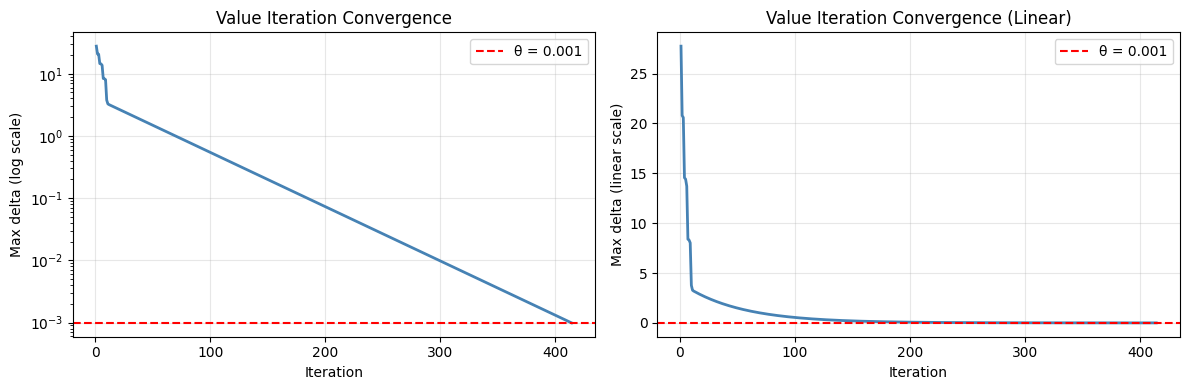

Converged at iteration 414


In [8]:
# ── Convergence plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(range(1, len(delta_history)+1), delta_history, color='steelblue', lw=2)
axes[0].axhline(THETA, color='red', linestyle='--', label=f'θ = {THETA}')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Max delta (log scale)')
axes[0].set_title('Value Iteration Convergence')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(delta_history)+1), delta_history, color='steelblue', lw=2)
axes[1].axhline(THETA, color='red', linestyle='--', label=f'θ = {THETA}')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Max delta (linear scale)')
axes[1].set_title('Value Iteration Convergence (Linear)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Converged at iteration {len(delta_history)}')

In [9]:
# ── Key value spot-checks ────────────────────────────────────────────────
print('=== Optimal Value Spot-Checks ===')
checks = [
    (START_POS[0], START_POS[1], MAX_BATTERY, 0),
    (START_POS[0], START_POS[1], 1, 0),
    (2, 2, 5, 0),   # charging station
    (0, 2, 5, 0),   # danger zone
    (1, 4, 5, 0),   # rescue target 0 (not yet rescued)
    (1, 4, 5, 1),   # rescue target 0 (already rescued)
    (4, 2, 5, 0),   # rescue target 1 (not yet rescued)
    (4, 2, 5, 2),   # rescue target 1 (already rescued)
]
for s in checks:
    v = V.get(s, 0.0)
    p = ACTION_NAMES[policy.get(s, HOVER)]
    print(f'  V*{s} = {v:8.3f}   π*={p}')

=== Optimal Value Spot-Checks ===
  V*(0, 0, 10, 0) =  205.434   π*=Down
  V*(0, 0, 1, 0) =  -21.000   π*=Up
  V*(2, 2, 5, 0) =  213.296   π*=Down
  V*(0, 2, 5, 0) =  212.999   π*=Down
  V*(1, 4, 5, 0) =  213.508   π*=Right
  V*(1, 4, 5, 1) =  195.463   π*=Down
  V*(4, 2, 5, 0) =  216.462   π*=Down
  V*(4, 2, 5, 2) =  198.447   π*=Up


---
## Part 3 – Policy Visualisation

In [10]:
# ─────────────────────────────────────────────────────────────────────────
#  VISUALISATION HELPERS
# ─────────────────────────────────────────────────────────────────────────

CELL_COLORS = {
    CELL_S: '#A8D8EA',   # light blue – start
    CELL_F: '#F5F5DC',   # beige – free
    CELL_D: '#FF6B6B',   # red – danger
    CELL_R: '#6BCB77',   # green – rescue
    CELL_C: '#FFD93D',   # yellow – charging
    CELL_W: '#B5EAD7',   # mint – wind
    CELL_X: '#555555',   # dark grey – blocked
}

ACTION_ARROW = {UP: '↑', DOWN: '↓', LEFT: '←', RIGHT: '→', HOVER: 'H'}


def draw_policy_grid(ax, battery, mask, title):
    """
    Draw the 5×5 policy grid on `ax` for fixed battery and rescue_mask.
    Each cell shows the base cell type (colour) and the optimal action (arrow/H).
    """
    ax.set_xlim(0, GRID_SIZE)
    ax.set_ylim(0, GRID_SIZE)
    ax.set_aspect('equal')
    ax.set_xticks(range(GRID_SIZE + 1))
    ax.set_yticks(range(GRID_SIZE + 1))
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax.set_title(title, fontsize=10, pad=6)

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            # Row 0 in grid = top; flip vertically for display
            disp_r = (GRID_SIZE - 1) - r

            cell_type = BASE_GRID[r][c]

            # Colour
            if cell_type == CELL_R:
                idx  = RESCUE_POSITIONS.index((r, c))
                color = '#C8E6C9' if (mask >> idx) & 1 else CELL_COLORS[CELL_R]
            else:
                color = CELL_COLORS.get(cell_type, '#FFFFFF')

            rect = plt.Rectangle((c, disp_r), 1, 1,
                                  facecolor=color, edgecolor='grey', lw=0.8)
            ax.add_patch(rect)

            # Cell label
            ax.text(c + 0.5, disp_r + 0.82, cell_type,
                    ha='center', va='center', fontsize=8, color='#333333', alpha=0.6)

            # Policy arrow / label
            if cell_type == CELL_X:
                ax.text(c + 0.5, disp_r + 0.38, '✗',
                        ha='center', va='center', fontsize=14, color='white')
            else:
                s = (r, c, battery, mask)
                a = policy.get(s, HOVER)
                v = V.get(s, 0.0)
                ax.text(c + 0.5, disp_r + 0.45, ACTION_ARROW[a],
                        ha='center', va='center', fontsize=14, color='#1A1A2E', fontweight='bold')
                ax.text(c + 0.5, disp_r + 0.18, f'{v:.1f}',
                        ha='center', va='center', fontsize=6.5, color='#444')

    # Row/col labels
    for i in range(GRID_SIZE):
        ax.text(i + 0.5, -0.25, str(i), ha='center', fontsize=8, color='grey')
        ax.text(-0.25, (GRID_SIZE - 1 - i) + 0.5, str(i), ha='center', fontsize=8, color='grey')

    ax.text(GRID_SIZE / 2, -0.45, 'col', ha='center', fontsize=8, color='grey')
    ax.text(-0.55, GRID_SIZE / 2, 'row', ha='center', fontsize=8, color='grey',
            rotation=90, va='center')


print('Helper functions defined.')

Helper functions defined.


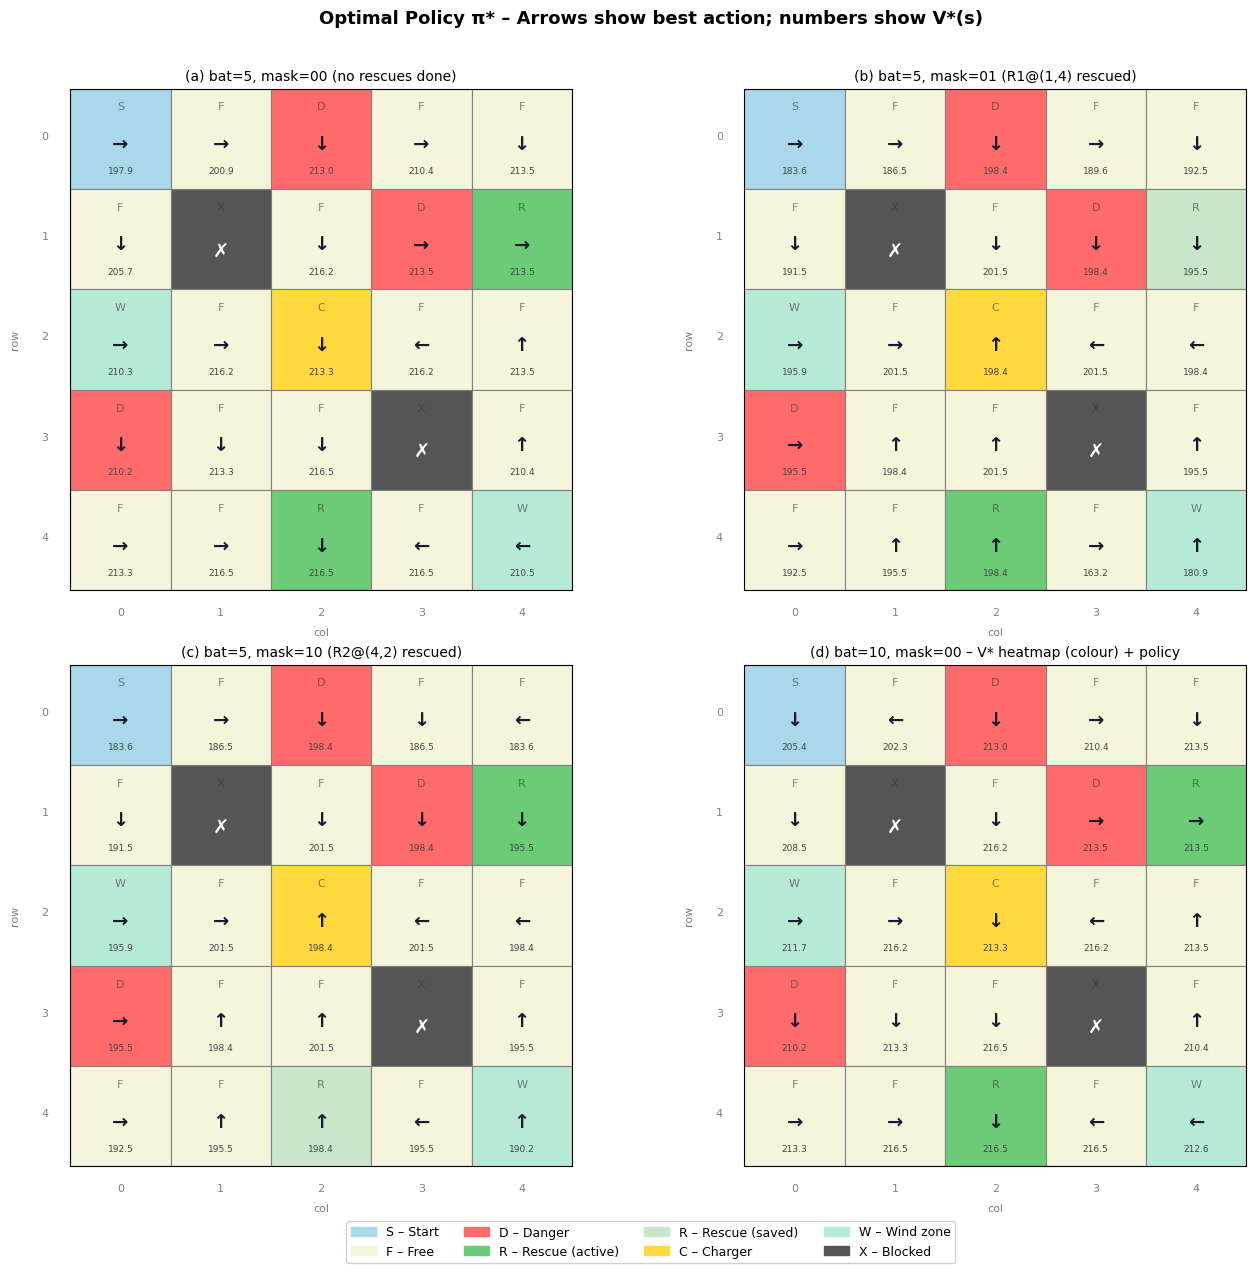

Policy visualisation complete.


In [11]:
# ── 4-panel policy grid: mask ∈ {0,1,2}, battery=5 + mask=0 bat=10 ───────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

configs = [
    (5, 0, '(a) bat=5, mask=00 (no rescues done)'),
    (5, 1, '(b) bat=5, mask=01 (R1@(1,4) rescued)'),
    (5, 2, '(c) bat=5, mask=10 (R2@(4,2) rescued)'),
    (10, 0, '(d) bat=10, mask=00 – V* heatmap (colour) + policy'),
]

for ax, (bat, msk, title) in zip(axes.flat, configs):
    draw_policy_grid(ax, bat, msk, title)

# Legend
legend_patches = [
    mpatches.Patch(color=CELL_COLORS[CELL_S], label='S – Start'),
    mpatches.Patch(color=CELL_COLORS[CELL_F], label='F – Free'),
    mpatches.Patch(color=CELL_COLORS[CELL_D], label='D – Danger'),
    mpatches.Patch(color=CELL_COLORS[CELL_R], label='R – Rescue (active)'),
    mpatches.Patch(color='#C8E6C9',           label='R – Rescue (saved)'),
    mpatches.Patch(color=CELL_COLORS[CELL_C], label='C – Charger'),
    mpatches.Patch(color=CELL_COLORS[CELL_W], label='W – Wind zone'),
    mpatches.Patch(color=CELL_COLORS[CELL_X], label='X – Blocked'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Optimal Policy π* – Arrows show best action; numbers show V*(s)',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('policy_grid.png', dpi=120, bbox_inches='tight')
plt.show()
print('Policy visualisation complete.')

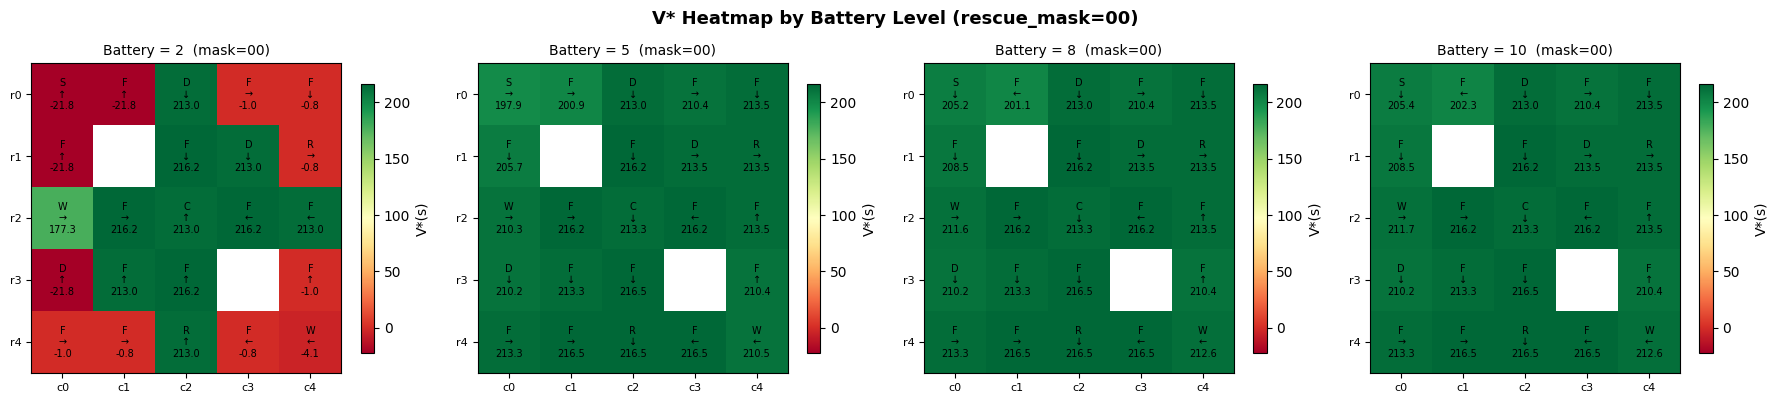

In [12]:
# ── V* heatmap panels for varying battery (mask=0) ────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
battery_levels = [2, 5, 8, 10]
cmap = plt.cm.RdYlGn

for ax, bat in zip(axes, battery_levels):
    data = np.zeros((GRID_SIZE, GRID_SIZE))
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if (r, c) in BLOCKED_POSITIONS:
                data[r, c] = np.nan
            else:
                data[r, c] = V.get((r, c, bat, 0), 0.0)

    im = ax.imshow(data, cmap=cmap, origin='upper',
                   vmin=np.nanmin([V.get((r,c,b,0),0) for r in range(GRID_SIZE)
                                   for c in range(GRID_SIZE)
                                   for b in range(1,MAX_BATTERY+1)
                                   if (r,c) not in BLOCKED_POSITIONS]),
                   vmax=np.nanmax([V.get((r,c,b,0),0) for r in range(GRID_SIZE)
                                   for c in range(GRID_SIZE)
                                   for b in range(1,MAX_BATTERY+1)
                                   if (r,c) not in BLOCKED_POSITIONS]))

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            cell = BASE_GRID[r][c]
            if cell == CELL_X:
                ax.text(c, r, 'X', ha='center', va='center', fontsize=12,
                        color='white', fontweight='bold')
            else:
                v_val = V.get((r, c, bat, 0), 0.0)
                a_lbl = ACTION_ARROW[policy.get((r,c,bat,0), HOVER)]
                ax.text(c, r, f'{cell}\n{a_lbl}\n{v_val:.1f}',
                        ha='center', va='center', fontsize=7, color='black')

    ax.set_title(f'Battery = {bat}  (mask=00)', fontsize=10)
    ax.set_xticks(range(GRID_SIZE))
    ax.set_yticks(range(GRID_SIZE))
    ax.set_xticklabels([f'c{i}' for i in range(GRID_SIZE)], fontsize=8)
    ax.set_yticklabels([f'r{i}' for i in range(GRID_SIZE)], fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8, label='V*(s)')

fig.suptitle('V* Heatmap by Battery Level (rescue_mask=00)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vstar_heatmap_battery.png', dpi=120, bbox_inches='tight')
plt.show()

In [13]:
# ── Simulate an episode using optimal policy (greedy) ─────────────────────
np.random.seed(0)
env2 = DroneRescueEnv()
obs  = env2.reset()
trajectory = [obs]
total_rew  = 0.0
done       = False

print('=== Optimal Policy Trajectory ===')
print(f'Start: pos=({obs[0]},{obs[1]})  bat={obs[2]}  mask={obs[3]:02b}')

while not done:
    a = policy.get(obs, HOVER)
    obs, rew, done, info = env2.step(a)
    trajectory.append(obs)
    total_rew += rew
    r_t, c_t, b_t, m_t = obs
    print(f'  Step {info["step"]:2d}: action={ACTION_NAMES[a]:6s}  '
          f'pos=({r_t},{c_t})  bat={b_t:2d}  mask={m_t:02b}  rew={rew:+.0f}')

print(f'\nEpisode finished. Total reward: {total_rew:+.0f}  Steps: {info["step"]}')
if m_t == ALL_RESCUED_MASK:
    print('✓ All civilians rescued!')
elif b_t == 0:
    print('✗ Battery exhausted.')

=== Optimal Policy Trajectory ===
Start: pos=(0,0)  bat=10  mask=00
  Step  1: action=Down    pos=(1,0)  bat= 9  mask=00  rew=-1
  Step  2: action=Down    pos=(2,0)  bat= 8  mask=00  rew=-1
  Step  3: action=Right   pos=(2,1)  bat= 7  mask=00  rew=-1
  Step  4: action=Right   pos=(2,2)  bat=10  mask=00  rew=+5
  Step  5: action=Down    pos=(3,2)  bat= 9  mask=00  rew=-1
  Step  6: action=Down    pos=(4,2)  bat= 8  mask=10  rew=+20
  Step  7: action=Up      pos=(3,2)  bat= 7  mask=10  rew=-1
  Step  8: action=Up      pos=(2,2)  bat=10  mask=10  rew=+5
  Step  9: action=Up      pos=(1,2)  bat= 9  mask=10  rew=-1
  Step 10: action=Down    pos=(2,2)  bat=10  mask=10  rew=+5
  Step 11: action=Up      pos=(1,2)  bat= 9  mask=10  rew=-1
  Step 12: action=Down    pos=(2,2)  bat=10  mask=10  rew=+5
  Step 13: action=Up      pos=(1,2)  bat= 9  mask=10  rew=-1
  Step 14: action=Down    pos=(2,2)  bat=10  mask=10  rew=+5
  Step 15: action=Up      pos=(1,2)  bat= 9  mask=10  rew=-1
  Step 16: actio

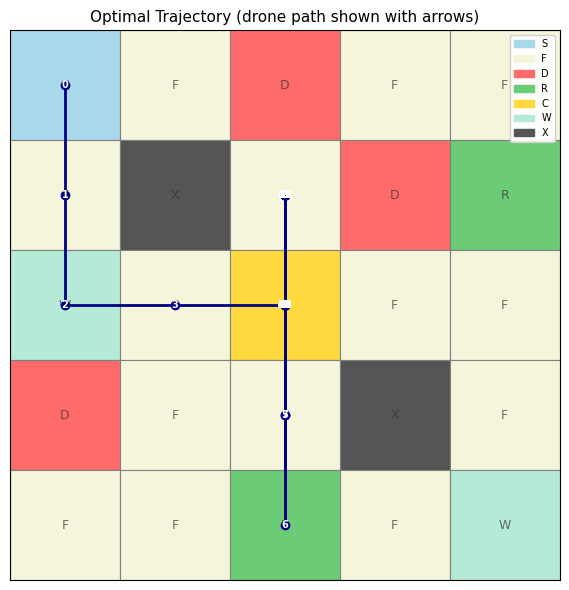

In [14]:
# ── Trajectory visualisation ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, GRID_SIZE)
ax.set_ylim(0, GRID_SIZE)
ax.set_aspect('equal')
ax.set_xticks(range(GRID_SIZE + 1))
ax.set_yticks(range(GRID_SIZE + 1))
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.set_title('Optimal Trajectory (drone path shown with arrows)', fontsize=11)

# Draw grid cells
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        disp_r = (GRID_SIZE - 1) - r
        cell_type = BASE_GRID[r][c]
        color = CELL_COLORS.get(cell_type, '#FFFFFF')
        rect = plt.Rectangle((c, disp_r), 1, 1, facecolor=color,
                              edgecolor='grey', lw=0.8)
        ax.add_patch(rect)
        ax.text(c + 0.5, disp_r + 0.5, cell_type, ha='center', va='center',
                fontsize=9, color='#333', alpha=0.7)

# Draw trajectory
traj_x = [c + 0.5 for _, c, _, _ in trajectory]
traj_y = [(GRID_SIZE - 1 - r) + 0.5 for r, _, _, _ in trajectory]

ax.plot(traj_x, traj_y, 'o-', color='navy', lw=2, markersize=6, zorder=5)
for i, (tx, ty) in enumerate(zip(traj_x, traj_y)):
    ax.annotate(str(i), (tx, ty), fontsize=7, ha='center', va='center',
                color='white', fontweight='bold', zorder=6)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in CELL_COLORS.items()]
ax.legend(handles=legend_patches, loc='upper right', fontsize=7, framealpha=0.9)

plt.tight_layout()
plt.savefig('trajectory.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Part 4 – State-Value Analysis

We fix the **rescue mask** and **battery level**, then vary the **drone position** across all 25 cells, plotting $V^*(s)$ as a heatmap. This lets us visualise which positions the drone should prefer at different stages of the mission.

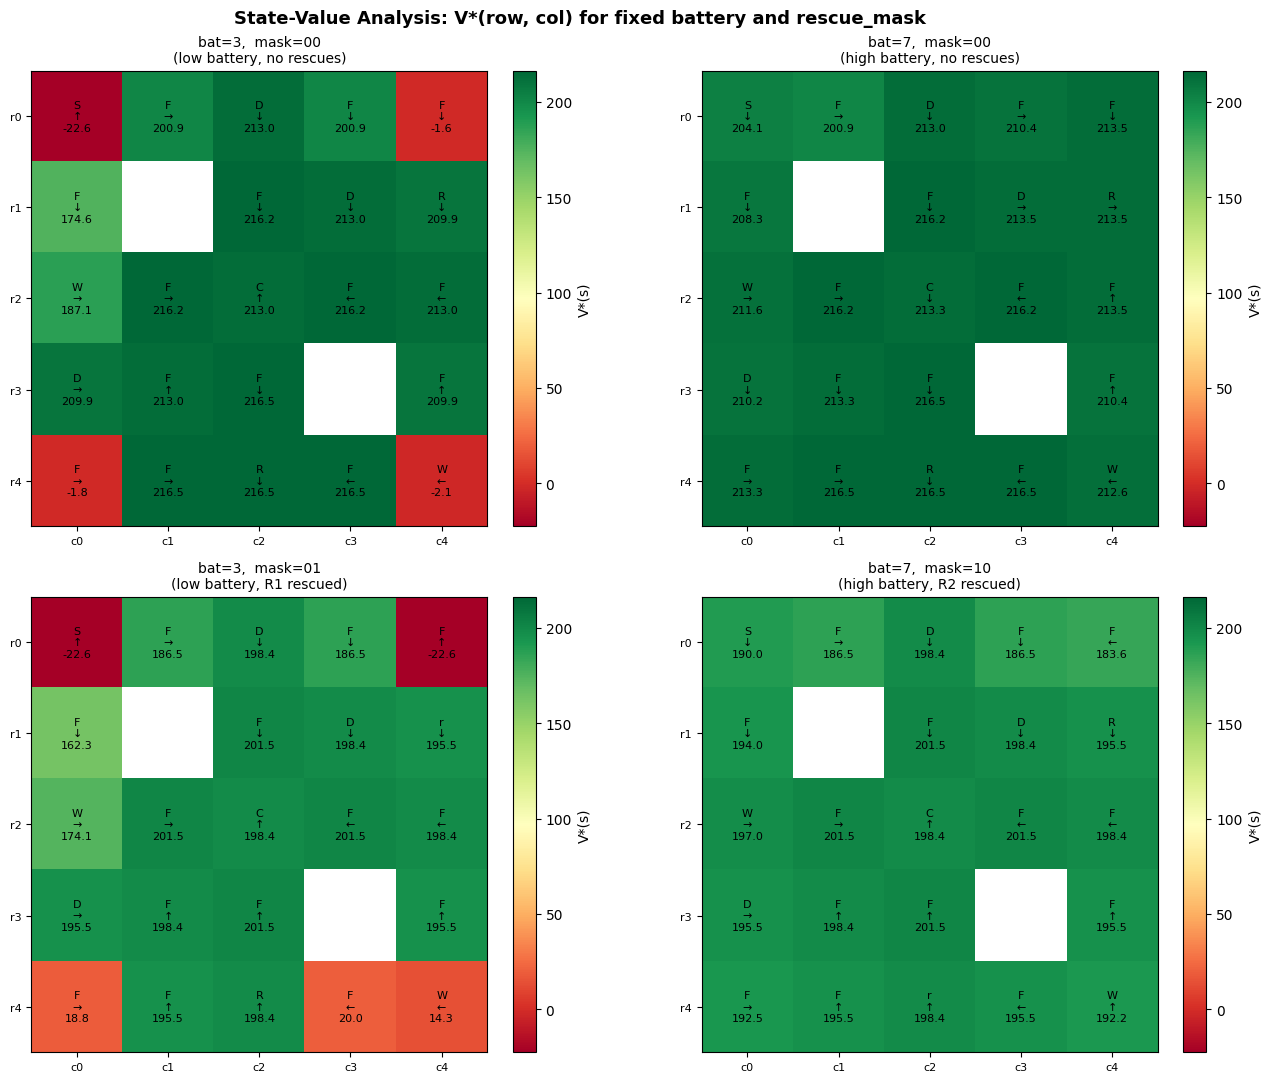

In [15]:
# ─────────────────────────────────────────────────────────────────────────
#  PART 4 – STATE-VALUE HEATMAPS
#  Fix (battery, mask), vary (row, col)
# ─────────────────────────────────────────────────────────────────────────

slices = [
    (3,  0, 'bat=3,  mask=00\n(low battery, no rescues)'),
    (7,  0, 'bat=7,  mask=00\n(high battery, no rescues)'),
    (3,  1, 'bat=3,  mask=01\n(low battery, R1 rescued)'),
    (7,  2, 'bat=7,  mask=10\n(high battery, R2 rescued)'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
cmap = plt.cm.RdYlGn

global_vmin = min(V.get((r,c,b,m), 0.0)
                  for r in range(GRID_SIZE) for c in range(GRID_SIZE)
                  for b in range(1, MAX_BATTERY+1) for m in range(ALL_RESCUED_MASK)
                  if (r,c) not in BLOCKED_POSITIONS)
global_vmax = max(V.get((r,c,b,m), 0.0)
                  for r in range(GRID_SIZE) for c in range(GRID_SIZE)
                  for b in range(1, MAX_BATTERY+1) for m in range(ALL_RESCUED_MASK)
                  if (r,c) not in BLOCKED_POSITIONS)

for ax, (bat, msk, title) in zip(axes.flat, slices):
    data = np.full((GRID_SIZE, GRID_SIZE), np.nan)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if (r, c) not in BLOCKED_POSITIONS:
                data[r, c] = V.get((r, c, bat, msk), 0.0)

    im = ax.imshow(data, cmap=cmap, origin='upper',
                   vmin=global_vmin, vmax=global_vmax)

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            cell = BASE_GRID[r][c]
            if cell == CELL_X:
                ax.text(c, r, 'X', ha='center', va='center',
                        fontsize=13, color='white', fontweight='bold')
            else:
                v_val  = V.get((r, c, bat, msk), 0.0)
                a_lbl  = ACTION_ARROW[policy.get((r,c,bat,msk), HOVER)]
                # Adjust rescue target label for rescued status
                disp_c = cell
                if cell == CELL_R:
                    idx = RESCUE_POSITIONS.index((r,c))
                    disp_c = 'r' if (msk >> idx) & 1 else 'R'
                ax.text(c, r, f'{disp_c}\n{a_lbl}\n{v_val:.1f}',
                        ha='center', va='center', fontsize=8,
                        color='black', fontweight='normal')

    ax.set_title(title, fontsize=10, pad=6)
    ax.set_xticks(range(GRID_SIZE))
    ax.set_yticks(range(GRID_SIZE))
    ax.set_xticklabels([f'c{i}' for i in range(GRID_SIZE)], fontsize=8)
    ax.set_yticklabels([f'r{i}' for i in range(GRID_SIZE)], fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='V*(s)')

fig.suptitle('State-Value Analysis: V*(row, col) for fixed battery and rescue_mask',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('state_value_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

### Observations from State-Value Analysis

1. **High-battery vs low-battery slices** (`bat=7` vs `bat=3`, `mask=00`):  
   - With `bat=7`, cells near both rescue targets receive high $V^*$ because the drone has enough power to complete both rescues.  
   - With `bat=3`, $V^*$ is dominated by proximity to the charging station (2,2). Cells far from the charger have near-zero or negative values because the drone risks battery death before reaching any target.

2. **Rescue progress effects** (`mask=01` vs `mask=10`):  
   - Once R1@(1,4) is rescued (`mask=01`), $V^*$ shifts – the optimal path no longer needs to visit (1,4), so cells on the upper-right path lose value.  
   - The drone's attention moves exclusively toward R2@(4,2); values near (4,2) increase relative to the `mask=00` slice.

3. **Danger zone avoidance** (D at (0,2), (1,3), (3,0)):  
   - These cells show consistently lower $V^*$ than their safe neighbours. The policy steers the drone away from them whenever a safe path exists.

4. **Wind zone uncertainty** (W at (2,0), (4,4)):  
   - $V^*$ at wind zones is slightly lower than equivalent safe cells at the same distance from targets, because stochastic wind can waste a step by pushing the drone off-course toward the danger zone at (3,0).

5. **Charging station gravity** (C at (2,2)):  
   - At low battery, the charging station has the highest $V^*$ in the entire grid – it is the most valuable cell to visit because it enables completing the full rescue mission.

---
## Part 5 – DP Scalability Discussion

### Curse of Dimensionality

The **state space** of the drone rescue MDP is:

$$|\mathcal{S}| = |\text{positions}| \times |\text{battery levels}| \times 2^{|\text{rescue targets}|}$$

For the current assignment (5×5, 2 targets, battery 1–10):
$$|\mathcal{S}| = 23 \times 10 \times 4 = 920 \text{ states}$$

---

### How State Space Grows

#### 1. Larger grid (10×10)

With a 10×10 grid, positions alone jump to ~100 cells. If we scale other parameters proportionally:
- 5 rescue targets → $2^5 = 32$ rescue combinations  
- Max battery = 20 (larger grid requires more power)  
$$|\mathcal{S}| \approx 100 \times 20 \times 32 = 64{,}000 \text{ states}$$

That is a **~70× increase** from 920. Value Iteration time complexity is $O(|\mathcal{S}|^2 \cdot |\mathcal{A}|)$ per iteration, so runtime grows at least quadratically with state space.

#### 2. More rescue targets

Rescue status is the most explosive dimension. Each added target **doubles** the rescue mask states:

| Targets | Rescue masks | States (5×5, bat=10) |
|---------|-------------|---------------------|
| 2 | 4 | 920 |
| 4 | 16 | 3,680 |
| 6 | 64 | 14,720 |
| 10 | 1,024 | 235,520 |
| 15 | 32,768 | 7,536,640 |

At 15 rescue targets, DP becomes computationally intractable on a standard CPU even with a 5×5 grid.

#### 3. Dynamic weather conditions

If weather (wind strength, storm patterns) is added as a dynamic variable with $W$ states, the state space multiplies further:
$$|\mathcal{S}| \times W$$

With a Markov weather model of 10 states, the 64,000-state 10×10 example becomes **640,000 states**. Each weather state may require a different policy, making tabular DP infeasible.

---

### Why DP Becomes Difficult

| Issue | Detail |
|-------|--------|
| **Memory** | Storing $V^*(s)$ and $\pi^*(s)$ for millions of states requires GB of RAM |
| **Computation** | Each VI iteration visits every state × every action × every next state |
| **Model required** | DP needs exact transition probabilities $T(s,a,s')$ — unknown in the real world |
| **Convergence** | More states = more iterations needed before $\delta < \theta$ |
| **Continuous spaces** | Real drone physics (GPS, altitude, wind speed) are continuous — DP requires discretisation, losing accuracy |

---

### How Deep RL Helps

**Deep Q-Networks (DQN)** and related methods replace the lookup table $V^*(s)$ with a neural network $Q_\theta(s,a)$:

- The network **generalises** across similar states, so it doesn't need to enumerate every state explicitly.
- It **learns from experience** (sampled trajectories) rather than requiring an explicit model.
- Methods like **Proximal Policy Optimisation (PPO)** or **Soft Actor-Critic (SAC)** work directly in **continuous state and action spaces**, matching real drone hardware.
- **Transfer learning**: a neural policy trained in simulation can be fine-tuned on real hardware.

### Relation to Real-World Autonomous Drones

Real disaster-response drones face:
- Continuous GPS position + altitude + heading (infinite state space)
- Unknown environment map (no transition model)
- Multiple cooperating drones (multi-agent)
- Real-time constraints (policy must execute in milliseconds)

DP is suitable for **small-scale planning** (pre-computed waypoint graphs, local replanning) but must be replaced by **Deep RL or model-predictive control** at scale. Practical systems like DJI's autonomous navigation combine:
1. Classical planners (Dijkstra/A*) for waypoint routing on a discretised map
2. Deep RL for reactive local avoidance (real-time sensor data)
3. Battery/mission planning heuristics derived from offline DP solutions on simplified models

**Conclusion**: DP is an excellent conceptual and small-scale tool, but its exponential state-space growth makes it insufficient for realistic large-scale drone rescue — precisely where Deep RL shines.

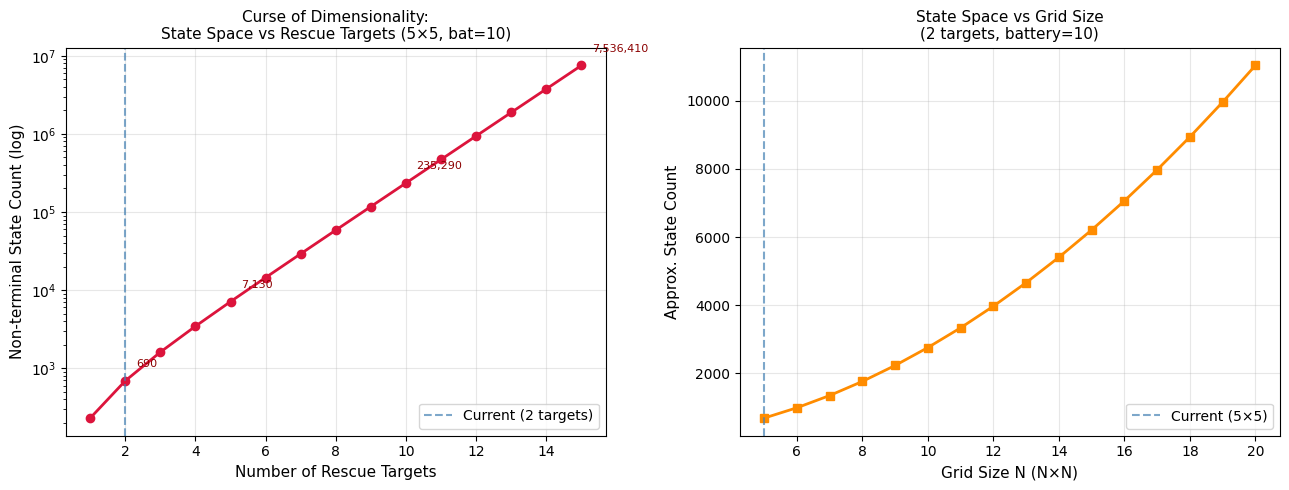

Scalability plot saved.


In [16]:
# ── Scalability illustration plot ────────────────────────────────────────
import math

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: State space vs number of rescue targets (5x5 grid, bat=10)
targets = range(1, 16)
states_vs_targets = [23 * 10 * (2**t - 1) for t in targets]  # subtract 1 for all-rescued terminal
axes[0].semilogy(targets, states_vs_targets, 'o-', color='crimson', lw=2)
axes[0].axvline(2, color='steelblue', linestyle='--', alpha=0.7, label='Current (2 targets)')
axes[0].set_xlabel('Number of Rescue Targets', fontsize=11)
axes[0].set_ylabel('Non-terminal State Count (log)', fontsize=11)
axes[0].set_title('Curse of Dimensionality:\nState Space vs Rescue Targets (5×5, bat=10)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Annotate
for t, s in zip([2, 5, 10, 15], [states_vs_targets[t-1] for t in [2, 5, 10, 15]]):
    axes[0].annotate(f'{s:,}', xy=(t, s), xytext=(t+0.3, s*1.5),
                     fontsize=8, color='darkred')

# Panel 2: State space vs grid size (2 targets, bat=10, 90% cells valid)
grid_sizes = range(5, 21)
states_vs_grid = [int((g*g * 0.92) * 10 * (2**2 - 1)) for g in grid_sizes]
axes[1].plot(grid_sizes, states_vs_grid, 's-', color='darkorange', lw=2)
axes[1].axvline(5, color='steelblue', linestyle='--', alpha=0.7, label='Current (5×5)')
axes[1].set_xlabel('Grid Size N (N×N)', fontsize=11)
axes[1].set_ylabel('Approx. State Count', fontsize=11)
axes[1].set_title('State Space vs Grid Size\n(2 targets, battery=10)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scalability.png', dpi=120, bbox_inches='tight')
plt.show()
print('Scalability plot saved.')

In [17]:
# ── Final Summary ────────────────────────────────────────────────────────
print('=' * 60)
print('ASSIGNMENT SUMMARY')
print('=' * 60)
print(f'Student ID          : 2025ab05032  (last digit = 2)')
print(f'Grid                : {GRID_SIZE}×{GRID_SIZE}')
print(f'Max battery         : {MAX_BATTERY}')
print(f'Wind probability    : {WIND_PROB*100:.0f}%')
print(f'Max steps           : {MAX_STEPS}')
print(f'Rescue targets      : {RESCUE_POSITIONS}')
print(f'Charging station    : {CHARGING_POSITIONS}')
print(f'Danger zones        : {DANGER_POSITIONS}')
print(f'Blocked cells       : {sorted(BLOCKED_POSITIONS)}')
print()
print(f'States enumerated   : {len(all_states)}')
print(f'VI iterations       : {len(delta_history)}')
print(f'Final delta         : {delta_history[-1]:.2e}')
print(f'Convergence runtime : {elapsed:.3f} s')
print()
s0 = (START_POS[0], START_POS[1], MAX_BATTERY, 0)
print(f'V*(start, bat=10, mask=0) = {V.get(s0, 0.0):.3f}')
print(f'π*(start, bat=10, mask=0) = {ACTION_NAMES[policy.get(s0, HOVER)]}')
print('=' * 60)

ASSIGNMENT SUMMARY
Student ID          : 2025ab05032  (last digit = 2)
Grid                : 5×5
Max battery         : 10
Wind probability    : 20%
Max steps           : 50
Rescue targets      : [(1, 4), (4, 2)]
Charging station    : [(2, 2)]
Danger zones        : [(0, 2), (1, 3), (3, 0)]
Blocked cells       : [(1, 1), (3, 3)]

States enumerated   : 690
VI iterations       : 414
Final delta         : 9.88e-04
Convergence runtime : 12.940 s

V*(start, bat=10, mask=0) = 205.434
π*(start, bat=10, mask=0) = Down
